# Homework 4: Clustering

## Setup

###  Step 1: Load the 20 Newsgroups Data

The 20 Newsgroups data set is a collection of approximately 20,000 newsgroup documents, partitioned (nearly) evenly across 20 different newsgroups. You can find additional information here:

In [2]:
from sklearn.datasets import fetch_20newsgroups

# You can load just a subset of categories for simplicity
categories = ['talk.religion.misc','alt.atheism','soc.religion.christian']

# Load the training data
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories)

In [3]:
# Example of accessing the data
print(newsgroups_train.data[0])
print(newsgroups_train.target[0])  # Corresponding target to the above document

# The size of the dataset can be found by checking the length of the data list
print(f"Training set size: {len(newsgroups_train.data)}")

From: jayne@mmalt.guild.org (Jayne Kulikauskas)
Subject: Re: Can sin "block" our prayers?
Organization: Kulikauskas home
Lines: 27

mike@boulder.snsc.unr.edu (Mike McCormick) writes:

> Not honoring our wives can cause our prayers to be hindered:
> 
>         You husbands likewise, live with your wives in
>         an understanding way, as with a weaker vessel,
>         since she is a woman;  and grant her honor as
>         a fellow heir of the grace of life, so that your
>         prayers may not be hindered.  I Peter 3:7

One interpretation I've heard of this verse is that it refers to the sin 
of physically abusing one's wife.  The husband is usually physically 
stronger than his wife but is not permitted to use this to dominate her.  
He must honor her as his sister in Christ.  This would therefore be an 
example of a specific sin that blocks prayer.

This verse also makes me think of the kind of husband who decides what 
is God's will for his family without consulting his wife. 

### Step 2:  Vectorize our data

We need to turn our text into sets of words.  However, we don't want words that are either too frequent or infrequent.  To do this, we'll use the TF-IDF vectorizer, and pick the top N (up to you!) words.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Sample data
documents = newsgroups_train.data

# Initialize the TFIDF vectorizer
vectorizer = TfidfVectorizer(stop_words="english")

# Fit the model and transform the documents
tfidf_matrix = vectorizer.fit_transform(documents)

print(vectorizer)

# Get the feature names
feature_names = vectorizer.get_feature_names_out()

# Get the TF-IDF scores for each feature
# Here, we sum the scores for each term across all documents
sums = tfidf_matrix.sum(axis=0)

# Connecting term to its sums score
data = []
for col, term in enumerate(feature_names):
    data.append((term, sums[0,col]))

# Create a DataFrame with the terms and their scores
ranking = pd.DataFrame(data, columns=['term','rank'])
ranking = ranking.sort_values('rank', ascending=False)

# Select top N terms
top_n = 2000
top_n_terms = ranking.head(top_n)
print(top_n_terms)

TfidfVectorizer(stop_words='english')
             term       rank
8230          edu  54.141299
10292         god  50.703659
5671          com  36.943917
16372      people  31.206464
12551       jesus  27.993130
...           ...        ...
10127     gentile   1.392175
16539  phenomenon   1.391443
9040    explained   1.391252
20759      strife   1.391217
9862          fri   1.390546

[2000 rows x 2 columns]


### Step 3: Join your terms with the Glove Vectors

GloVe vectors are word embeddings produced by the GloVe model, developed at Stanford. You can find them in the [Stanford GloVe repository](https://nlp.stanford.edu/projects/glove/). You'll probably want the smallest one (glove.6B). Once you have the embeddings, you’ll need to map these vectors to your data — keep in mind that the vectors come in different dimensions. I’ll use the 100-dimensional vectors for demonstration purposes.

In [5]:
# this code block is useful if you are working in a remote environment, such as Colab
# note that the download may take a while
#--ZB Note: I had to change this structure because I'm not working with a unix/linux shell.

import requests, zipfile, io

# Download the GloVe zip file
url = "https://nlp.stanford.edu/data/glove.6B.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()  # Extracts to current directory

In [9]:
import numpy as np

# Load GloVe vectors into a dictionary:
glove_vectors = {} #creation of an empty dictionary, below is filling the dictionary.
with open('glove.6B.100d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split() #splitting each line into a list of values
        word = values[0] #assigning value at index 0 to word
        vector = np.asarray(values[1:], dtype='float32') #index 1 (second element) array slicing, specifying datatype to store in 4 bytes of memory.
        glove_vectors[word] = vector

In [7]:
original_feature_names = top_n_terms.term

# Note that not all features are present in the glove vectors, so we'll filter here:
word_vectors = []
filtered_feature_names = []

for word in original_feature_names:
    if word in glove_vectors:
        word_vectors.append(glove_vectors[word])
        filtered_feature_names.append(word)

# Convert the list of vectors to a numpy array
word_vectors = np.array(word_vectors)

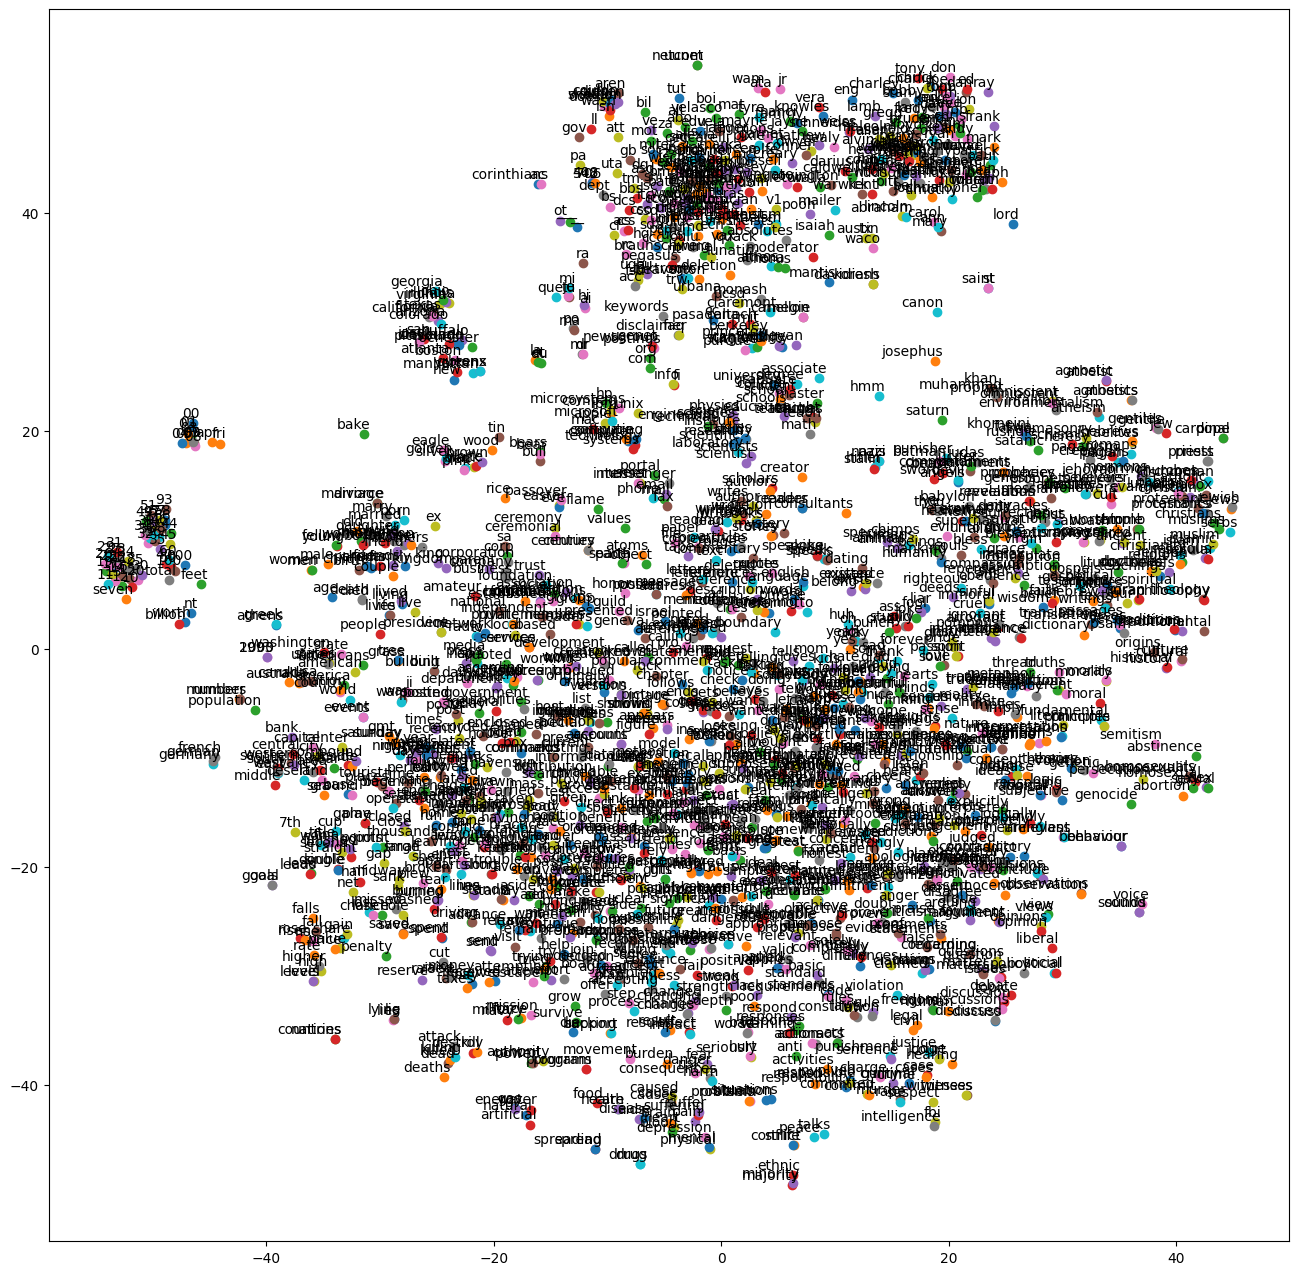

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Use t-SNE to project the vectors into a 2D space
tsne = TSNE(n_components=2)
word_vectors_2d = tsne.fit_transform(word_vectors)

# Plot the projection
plt.figure(figsize=(16, 16))
for i, word in enumerate(filtered_feature_names):
    if word in glove_vectors:  # Only plot words that were in the GloVe vectors
        plt.scatter(word_vectors_2d[i, 0], word_vectors_2d[i, 1])
        plt.annotate(word, xy=(word_vectors_2d[i, 0], word_vectors_2d[i, 1]), xytext=(5, 2),
                     textcoords='offset points', ha='right', va='bottom')
plt.show()

## Homework Beginning

Question 1: 

What happens if you project the data before you cluster? 
What happens if you don't? 

Explain which you prefer and why.

Answers-
So the above picture is what it looks like when we project the data before we cluster. As we can see it's not showing too much of a pattern, and we can sort of make out a few clusters but nothing major. Now the below shows two instances of clustering one with Kmeans and one with DBScan. Both cases we can clearly see defined clusters with Kmeans being the most prominent with 5 clusters popping out at us. I prefer post cluster because that's the point of clustering. We want to see that pattern, then we can associate the 5 different classes and see what words are inside of those classes. It gives value, and direction to the analysis when the clustering occurs. Unlike with unclustered data, it's jumbled and you're sort of staring at a mess. I like structure and organization so the Kmeans cluster plot truly makes me feel happier than seeing the pre cluster event.



Wanted to note, I elected to leave out the words for each bubble because it does become a complete mess so for the sake of this exercise I am electing to leave them off to clearly see the patterns. 

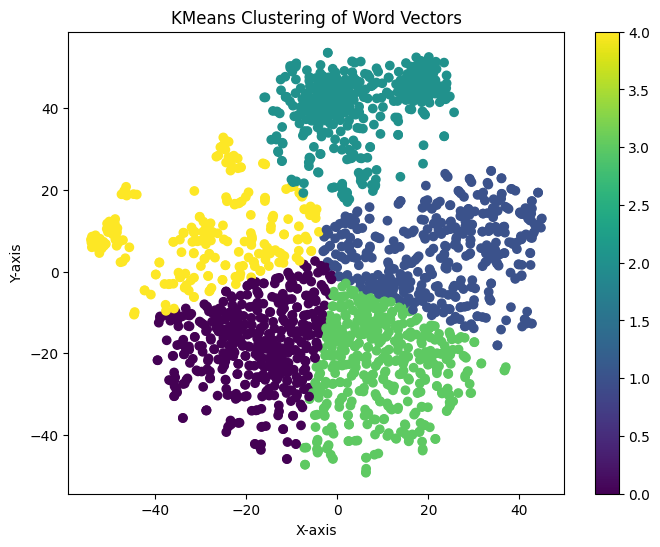

In [96]:
#variable containing the data is word_vectors_2d

#This is my Kmeans Clustering 
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k = 5
word_kmeans = KMeans(n_clusters=k, random_state=42)
word_kmeans.fit(word_vectors_2d)

labels = word_kmeans.labels_

plt.figure(figsize=(8, 6))
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], c=labels, cmap='viridis')
plt.title('KMeans Clustering of Word Vectors')
plt.xlabel('X-axis'); plt.ylabel('Y-axis')
plt.colorbar(); plt.show()

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


clusters=12, noise=3%


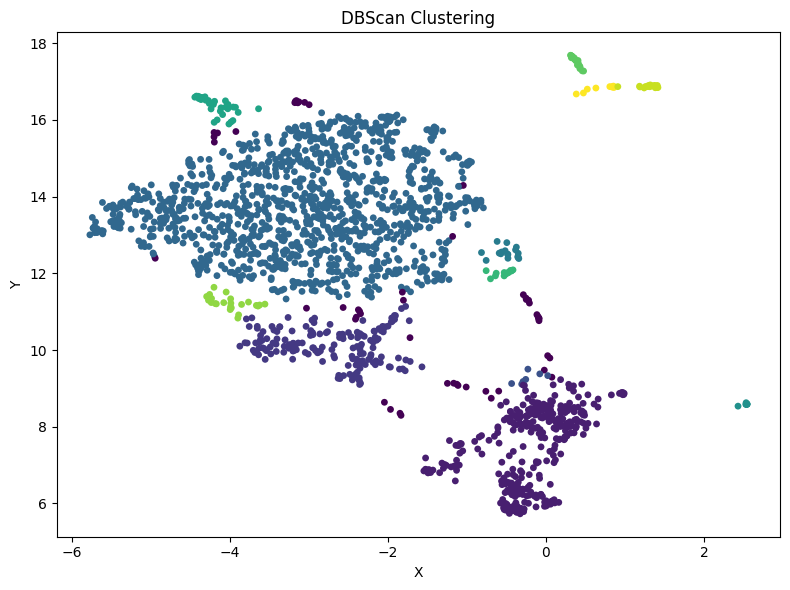

In [97]:
#This is my DBScan (Density-Based Spatial) Clustering 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from umap import UMAP
from matplotlib.colors import ListedColormap

reduc = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X = reduc.fit_transform(word_vectors)
dbscan = DBSCAN(eps=0.3, min_samples=10)
word_dbscan = dbscan.fit(X)
pred_y = word_dbscan.labels_

n_clusters = len(set(pred_y)) - (1 if -1 in pred_y else 0)
print(f"clusters={n_clusters}, noise={(pred_y == -1).mean():.0%}")

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=pred_y, cmap="viridis", edgecolor="none", s=24)
plt.title("DBScan Clustering")
plt.xlabel("X"); plt.ylabel("Y")
plt.tight_layout(); plt.show()

Question 2: 

What are the major clusterings in the different newsgroups?
Please summarize them for each of the three newsgroups. 

Notes: A summary goes well beyond a list of clustering elements, and tries to capture the underlying themes or characteristics that define each cluster within the newsgroups.

Inside the newsgroups we can begin seeing the patterns associated with each newsgroup. 

Starting off we'll look at alt.atheism, we see edu, keith, and caltech in our first cluster. I am going to assume that during vectorization edu was shortened to education which occurred during a stemming step (NLP) so our first cluster is focusing heavily on education specifically Caltech which is the California Institue of Technology and the name Keith which I would assume is most likely a professor of some sort at Caltech. Given this information and the context of the other groups and clusters that Keith said or published something either defending or protesting atheism in the realm of Religion. Looking at the second cluster we see cruel, sex, and genocide. With cruel we can imagine that the lecture or publication reflected on Christianities theology as one being cruel in some aspect. As most people know, Christianity does have a fairly violent past and can be seen as intolerant depending on their views. Examining sex we can guess that this could be talking about a couple different topics; one being Christianity, Catholisicm views sex outside of marriage as bad, and the other topic could pertain to the history of sexual exploitation by various Church leaders throughout history. Finally looking at genocide, this one's easy to surmise, throughout Christianities history there have been various wars and mass killings can take your pick of what one you want to imagine, the Protestent killings, the Christian genocides in Africa & the Middle East and various other occurences in history.

Looking at our second group soc.religion.christian right at first glance I notice a more gleeful tone, while atheism was somber. The first cluster being believe, subject, know; these are most likely talking about belief in God, the subjects in the Bible, and the third is most likely talking about knowing the different parts of the Bible and being knowledgable about them. Our second cluster is God, Jesus, and Church. These are very clear and understanding what they could be referencing. Then cluster three highlights life, man, and married. Christianity has an emphasis on men and women being married with the man leading so no surprise these are showing up together. Then life is obviously cherished in Christianity so it's again another word that would be mentioned or associated in these contexts. 

Then our third and final group talk.religion.misc is not really showing much to be honest. I won't do it here but if this was something I'd be working on in a larger capacity I would further prep the data to remove stop words, uninformative words, punctions and more. So, it's difficult to tell what the theme or idea being the third cluster. I am also electing to do it this way because it's good to see when data doesn't work the way you anticipate it. In the real world not everything is going to work out easily. 

In [91]:
#I used AI and Google to accomplish this step, I had no clue how to pull out the data to see what the clusters actually were.
import numpy as np

print(newsgroups_train.target_names)

y = newsgroups_train.target
names = newsgroups_train.target_names
vocab = vectorizer.vocabulary_            # term -> tfidf column
rows_by_cls = [np.where(y == i)[0] for i in range(len(names))]
words = np.array(filtered_feature_names)
labels = pred_y

out = {i: [] for i in range(len(names))}
for lbl in np.unique(labels):
    if lbl == -1: 
        continue
    idx = np.where(labels == lbl)[0]
    terms = [t for t in words[idx] if t in vocab]
    if not terms:
        continue
    cols = [vocab[t] for t in terms]
    scores = [float(tfidf_matrix[rows_by_cls[i]][:, cols].sum()) for i in range(len(names))]
    c = int(np.argmax(scores))  # dominant class for this cluster
    dom = np.asarray(tfidf_matrix[rows_by_cls[c]][:, cols].sum(axis=0)).ravel()
    top3 = [terms[j] for j in np.argsort(-dom)[:3]]
    out[c].append((lbl, scores[c], top3))

for i, name in enumerate(names):
    top = sorted(out[i], key=lambda x: x[1], reverse=True)[:3]
    print(f"\n{name}")
    for lbl, _, t3 in top:
        print(f"  Cluster {lbl}: {', '.join(t3)}")


['alt.atheism', 'soc.religion.christian', 'talk.religion.misc']

alt.atheism
  Cluster 0: edu, keith, caltech
  Cluster 9: cruel, sex, genocide

soc.religion.christian
  Cluster 3: believe, subject, know
  Cluster 1: god, jesus, church
  Cluster 6: life, man, married

talk.religion.misc
  Cluster 2: com, mr, usenet


Question 3:

How do the three newsgroups differ? 
How are they the same?

I would say these groups differ in the way they view religion. The athiest group clearly sees religion as a darker, cold, cruel, and malicious theme while also having discussions about education. Whereas the Christian group sees religion as a lighter, loving, and warm theme. See words like believe, God, and life which carry a brighter environment. Then as I mentioned before it seels like cluster three is a bit of a dud so hard to tell. 

Given that their individual themes are so different, one could say they're similar because they talk about religion. The very discussion of religion is bringing them together in a forumn that they may not have been communicating with each other at all. They're also the same in the way they have a consistency in their own themes, there's no outlier or random deviation from the topics that they're focused on. 